<h1 style="color:#ffffff; background-color:#3E4C59; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Day 2 — Building CNNs &amp; Transfer Learning</h1>
<h3 style="color:#52677A; text-align:center; font-weight:bold; margin-top:0;">Pooling, Data Augmentation, MobileNetV2, Freezing &amp; Fine-Tuning</h3>


<a id="toc"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Imports, Reproducibility &amp; GPU Check</a></li>
<li><a href="#section1">1. Day 2 Roadmap &amp; Dataset Structure</a></li>
<li><a href="#section2">2. Pooling — Shrinking Feature Maps</a></li>
<li><a href="#section3">3. Full CNN Architecture</a></li>
<li><a href="#section4">4. Data Augmentation</a></li>
<li><a href="#section5">5. Transfer Learning</a></li>
<li><a href="#section6">6. Hands-On Lab — Load &amp; Inspect the Image Dataset</a></li>
<li><a href="#section7">7. Model A — CNN From Scratch</a></li>
<li><a href="#section8">8. Model B — CNN + Data Augmentation</a></li>
<li><a href="#section9">9. Model C — Frozen MobileNetV2 Transfer Learning</a></li>
<li><a href="#section10">10. Fine-Tuning the Pre-trained Backbone</a></li>
<li><a href="#section11">11. Test Evaluation &amp; Model Comparison</a></li>
<li><a href="#section12">12. Common Mistakes &amp; Best Practices</a></li>
<li><a href="#section13">13. Final Reflection</a></li>
<li><a href="#section14">14. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Imports, Reproducibility &amp; GPU Check</h2>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> This notebook expects a folder named <code>dataset</code> beside <code>Day2.ipynb</code>. Inside it, the data must be organized as <code>dataset/train</code> and <code>dataset/test</code>. This matches the Week 7 Day 2 project structure exactly.
</div>


In [1]:
# Core imports
from pathlib import Path
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available      :", bool(tf.config.list_physical_devices("GPU")))
print("GPU devices        :", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
GPU available      : False
GPU devices        : []


<div style="border-left:5px solid #52677A; background-color:#eef2f4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#2C3640;">
<b>Why it matters in AI:</b> CNN training is compute-heavy. Reproducible seeds, a fixed validation split, and a clearly separated test set make the comparison between models meaningful instead of depending on a lucky run.
</div>


<a id="section1"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Day 2 Roadmap &amp; Dataset Structure</h2>
Day 2 moves from the convolution idea into a complete computer-vision workflow. The practical sequence is:

<ol style="line-height:1.8;">
<li>Build a small CNN from scratch.</li>
<li>Add data augmentation and compare validation behavior.</li>
<li>Reuse a pre-trained image model with transfer learning.</li>
<li>Freeze the backbone first, then optionally fine-tune part of it with a very small learning rate.</li>
<li>Compare accuracy, loss, confusion matrices, and training time.</li>
</ol>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#52677A; color:#D9C08C;"><th style="padding:8px; text-align:left;">Dataset Split</th><th style="padding:8px; text-align:left;">Class</th><th style="padding:8px; text-align:left;">Images in the supplied dataset</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Train</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Benign</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">6,289</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Train</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Malignant</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">5,590</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Test</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Benign</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">1,000</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Test</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Malignant</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">1,000</td></tr>
</table>
</div>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> All supplied images are RGB and 224×224 pixels. The notebook resizes them to <code>160×160</code> by default to make training faster while remaining compatible with MobileNetV2. Change <code>IMG_SIZE</code> to <code>(224, 224)</code> if you want to use the original resolution.
</div>


<a id="section2"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. Pooling — Shrinking Feature Maps</h2>
<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 What does pooling do?</h3>
After a convolution detects patterns, a pooling layer reduces the width and height of the resulting feature maps. <b>Max pooling</b> keeps the strongest value inside a small window, commonly 2×2.

For a 2×2 region such as <code>[[1, 5], [2, 3]]</code>, max pooling returns <code>5</code>. Repeating this over the image compresses the representation while preserving strong activations.


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#52677A; color:#D9C08C;"><th style="padding:8px; text-align:left;">Effect</th><th style="padding:8px; text-align:left;">Why It Helps</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Smaller feature maps</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Less memory and computation in deeper layers</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Keeps strong activations</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Preserves the most important detected pattern in each region</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Less sensitivity to tiny shifts</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">The feature can move slightly and still survive the pooling window</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Regularizing effect</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Reduces the amount of detail the network can memorize</td></tr>
</table>
</div>


In [2]:
# Small numerical example: 2x2 max pooling by hand
feature_map = np.array([
    [1, 5, 2, 0],
    [2, 3, 1, 4],
    [0, 1, 7, 2],
    [4, 2, 3, 6],
])

pooled = np.array([
    [feature_map[0:2, 0:2].max(), feature_map[0:2, 2:4].max()],
    [feature_map[2:4, 0:2].max(), feature_map[2:4, 2:4].max()],
])

print("Original feature map:\n", feature_map)
print("\nAfter 2x2 max pooling:\n", pooled)


Original feature map:
 [[1 5 2 0]
 [2 3 1 4]
 [0 1 7 2]
 [4 2 3 6]]

After 2x2 max pooling:
 [[5 4]
 [4 7]]


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> Pooling is not trying to understand the image by itself. The convolution learns <i>what</i> to detect; pooling mainly controls <i>how much spatial detail</i> is carried forward.
</div>


<a id="section3"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Full CNN Architecture</h2>
A typical CNN alternates <b>convolution</b> and <b>pooling</b> blocks to extract increasingly abstract visual features, then uses a classifier head to make the final prediction.


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#52677A; color:#D9C08C;"><th style="padding:8px; text-align:left;">Stage</th><th style="padding:8px; text-align:left;">Typical Layer</th><th style="padding:8px; text-align:left;">Role</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Input</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Input</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Receives the image tensor</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Normalization</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Rescaling(1./255)</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Maps pixel values from 0–255 to 0–1</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Feature extraction</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Conv2D</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Learns filters for edges, textures, and shapes</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Downsampling</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>MaxPooling2D</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Shrinks feature maps</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Vectorization</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Flatten</code> or <code>GlobalAveragePooling2D</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Turns spatial features into a compact representation</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Classifier</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Dense</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Maps learned features to the output class</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Output</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Dense(1, sigmoid)</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Binary probability: Benign vs Malignant</td></tr>
</table>
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 Why stack more than one convolution block?</h3>
Early convolution layers usually learn simple local patterns. Deeper layers combine those simple patterns into more meaningful structures. A hierarchy such as <b>edges → textures → shapes → class-specific features</b> is the central strength of CNNs.


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> For this binary dataset, the final layer uses one neuron with <code>sigmoid</code> and the loss is <code>binary_crossentropy</code>. A multi-class dataset would normally use one output per class with <code>softmax</code>.
</div>


<a id="section4"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. Data Augmentation</h2>
Image datasets can be too small for a CNN to generalize well. <b>Data augmentation</b> creates random, realistic variations of training images so the model sees a different version of the same underlying example across epochs.


In [3]:
# The augmentation pipeline used later in Model B and Model C
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#52677A; color:#D9C08C;"><th style="padding:8px; text-align:left;">Augmentation</th><th style="padding:8px; text-align:left;">What Changes</th><th style="padding:8px; text-align:left;">Reason</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Horizontal flip</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Mirrors the image</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Adds orientation variation when left/right direction is not the label</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Rotation</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Small angular changes</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Makes the classifier less sensitive to camera angle</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Zoom</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Small crop/scale changes</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Encourages robustness to subject size</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Contrast</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Slight intensity variation</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Adds tolerance to lighting/camera differences</td></tr>
</table>
</div>
<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> Apply augmentation to the <b>training</b> data only. Validation and test images should represent the real data distribution and must not be randomly altered during evaluation.
</div>


<a id="section5"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Transfer Learning</h2>
<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">5.1 The central idea</h3>
Training a strong visual feature extractor from scratch usually needs a very large dataset. <b>Transfer learning</b> starts from a CNN already trained on a huge image collection such as ImageNet. We reuse its general visual features and replace the original classifier with a small head for our own two classes.


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#52677A; color:#D9C08C;"><th style="padding:8px; text-align:left;">Phase</th><th style="padding:8px; text-align:left;">Backbone</th><th style="padding:8px; text-align:left;">Learning Rate</th><th style="padding:8px; text-align:left;">Purpose</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Frozen transfer learning</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Not trainable</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Normal (e.g. 1e-3)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Train only the new classifier head safely and quickly</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Fine-tuning</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Last layers trainable</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Very small (e.g. 1e-5)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Gently adapt higher-level features to the new dataset</td></tr>
</table>
</div>


<div style="border-left:5px solid #52677A; background-color:#eef2f4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#2C3640;">
<b>Why it matters in AI:</b> Pre-trained CNNs already contain useful edge, texture, and shape detectors. Reusing those learned filters often gives better results with less data and much less training time than learning every filter from random initialization.
</div>


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> Fine-tuning too early or with a large learning rate can destroy useful pre-trained weights. First train the new classifier while the backbone is frozen; only then unfreeze a small number of upper layers and recompile with a much smaller learning rate.
</div>


<a id="section6"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Hands-On Lab — Load &amp; Inspect the Image Dataset</h2>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Goal:</b> Use the supplied Benign/Malignant image dataset to complete the official Day 2 lab: baseline CNN → augmentation → frozen MobileNetV2 → comparison of validation/test behavior and training time.
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">6.1 Dataset path setup</h3>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Project structure:</b> Keep <code>Day2.ipynb</code> and the <code>dataset</code> folder in the same <code>Day 2</code> directory. The notebook will read the images directly from <code>dataset/train</code> and <code>dataset/test</code>.
</div>
<pre style="background-color:#202830; color:#f2f2f2; padding:14px; border-radius:6px; line-height:1.6;">Day 2/
├── dataset/
│   ├── train/
│   │   ├── Benign/
│   │   └── Malignant/
│   └── test/
│       ├── Benign/
│       └── Malignant/
├── Day2.ipynb
└── README.md</pre>


In [4]:
DATASET_ROOT = Path("dataset")
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

# Validate the expected structure before loading images.
required_folders = [
    TRAIN_DIR / "Benign",
    TRAIN_DIR / "Malignant",
    TEST_DIR / "Benign",
    TEST_DIR / "Malignant",
]
print("Dataset path is ready.")


Dataset path is ready.


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">6.2 Verify the class counts</h3>


In [5]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def count_images(folder):
    return sum(1 for p in Path(folder).rglob("*") if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS)

counts = []
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for class_name in ["Benign", "Malignant"]:
        n = count_images(split_dir / class_name)
        counts.append({"split": split_name, "class": class_name, "images": n})

counts_df = pd.DataFrame(counts)
display(counts_df)
print("Total images:", int(counts_df["images"].sum()))


,split,class,images
0,train,Benign,6289
1,train,Malignant,5590
2,test,Benign,1000
3,test,Malignant,1000


Total images: 13879


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">6.3 Build TensorFlow datasets</h3>


In [6]:
IMG_SIZE = (160, 160)   # Change to (224, 224) for original resolution
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20
EPOCHS = 5                # Increase if your GPU/time budget allows

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

# Keep test order stable for reports/confusion matrices.
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

CLASS_NAMES = train_ds.class_names
print("Class names:", CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.
Class names: ['Benign', 'Malignant']


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> TensorFlow sorts directory names alphabetically, so the expected label mapping is <code>Benign = 0</code> and <code>Malignant = 1</code>. Always print <code>CLASS_NAMES</code> instead of assuming the mapping.
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">6.4 Visualize a training batch</h3>


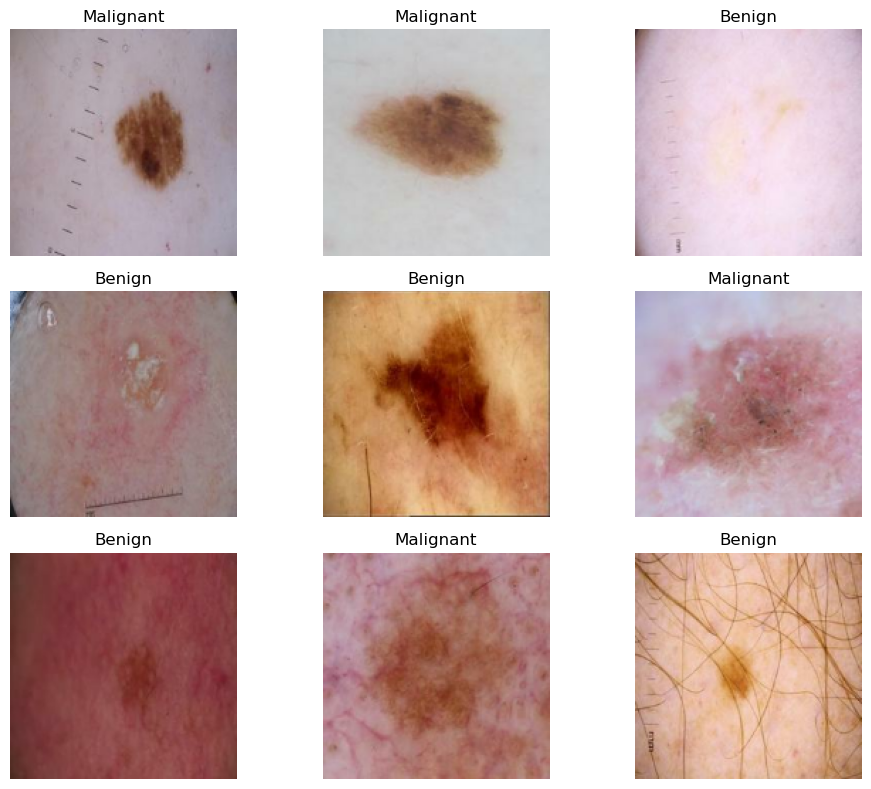

In [7]:
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_id = int(labels[i].numpy().squeeze())
        plt.title(CLASS_NAMES[label_id])
        plt.axis("off")
plt.tight_layout()
plt.show()


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">6.5 Training and plotting helpers</h3>


In [8]:
def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        )
    ]


def train_with_timer(model, train_data, val_data, epochs=EPOCHS, initial_epoch=0):
    start = time.perf_counter()
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        initial_epoch=initial_epoch,
        callbacks=make_callbacks(),
        verbose=1,
    )
    elapsed = time.perf_counter() - start
    return history, elapsed


def plot_history(history, title):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, hist["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, hist["loss"], label="Train Loss")
    plt.plot(epochs_range, hist["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


def compile_binary_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


<a id="section7"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Model A — CNN From Scratch</h2>
This is the first Day 2 benchmark: a compact CNN trained from random initialization with no augmentation. It gives us a clean baseline for the next experiments.


In [9]:
def build_scratch_cnn():
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = layers.Rescaling(1.0 / 255)(inputs)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="scratch_cnn")
    return compile_binary_model(model, learning_rate=1e-3)

scratch_model = build_scratch_cnn()
scratch_model.summary()


Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


c:\Users\sadee\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 78s 258ms/step - accuracy: 0.7343 - auc: 0.8153 - loss: 0.5224 - precision: 0.7679 - recall: 0.6191 - val_accuracy: 0.7891 - val_auc: 0.8820 - val_loss: 0.4394 - val_precision: 0.7845 - val_recall: 0.7755
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 196s 660ms/step - accuracy: 0.7850 - auc: 0.8645 - loss: 0.4575 - precision: 0.7712 - recall: 0.7683 - val_accuracy: 0.7975 - val_auc: 0.8972 - val_loss: 0.4130 - val_precision: 0.7991 - val_recall: 0.7747
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 102s 343ms/step - accuracy: 0.8080 - auc: 0.8954 - loss: 0.4092 - precision: 0.7864 - recall: 0.8092 - val_accuracy: 0.7869 - val_auc: 0.9027 - val_loss: 0.4875 - val_precision: 0.9029 - val_recall: 0.6253
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 160s 541ms/step - accuracy: 0.8157 - auc: 0.8962 - loss: 0.4058 - precision: 0.8031 - recall: 0.8027 - val_accuracy: 0.8029 - val_auc: 0.9029 - val_loss: 0.4081 - val_precision: 0.8567 - val_recall: 0.7100
Epoch 5/5
297/297 ━━━━━━━━━━━━━

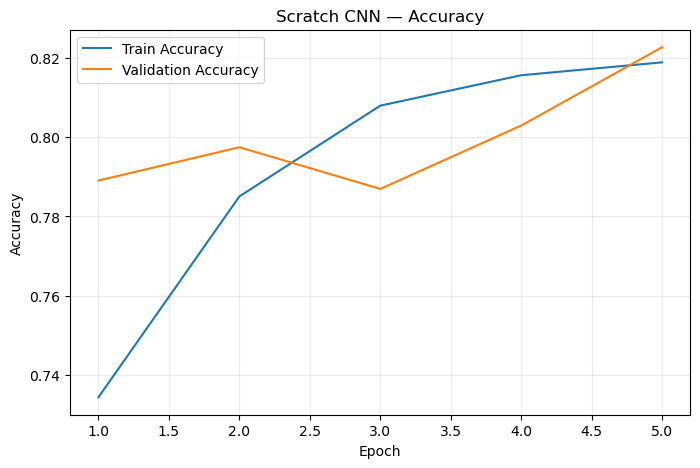

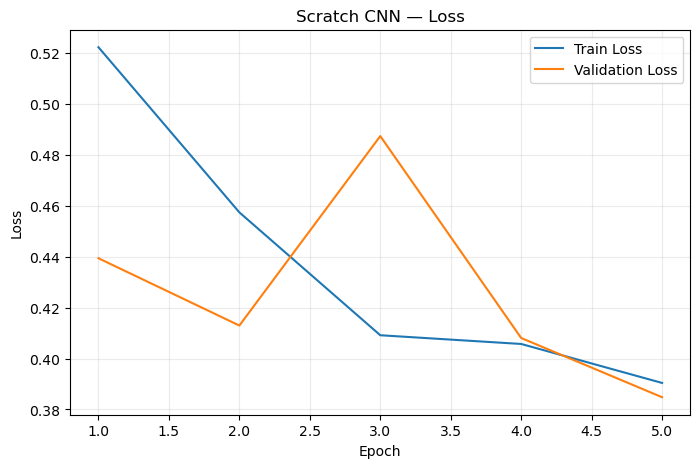

In [10]:
scratch_history, scratch_time = train_with_timer(
    scratch_model, train_ds, val_ds, epochs=EPOCHS
)
print(f"Scratch CNN training time: {scratch_time:.1f} seconds")
plot_history(scratch_history, "Scratch CNN")


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> Watch the gap between training and validation curves. If training accuracy keeps rising while validation accuracy stalls or validation loss increases, the model is starting to overfit.
</div>


<a id="section8"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Model B — CNN + Data Augmentation</h2>
Now we keep the same general CNN idea but place random augmentation before normalization. This tests whether additional image variation reduces overfitting and improves validation performance.


In [11]:
def build_augmented_cnn():
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="augmented_cnn")
    return compile_binary_model(model, learning_rate=1e-3)

aug_model = build_augmented_cnn()
aug_model.summary()


Model: "augmented_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 68s 225ms/step - accuracy: 0.7380 - auc: 0.8226 - loss: 0.5120 - precision: 0.7455 - recall: 0.6677 - val_accuracy: 0.7903 - val_auc: 0.8784 - val_loss: 0.4428 - val_precision: 0.7545 - val_recall: 0.8376
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 155s 523ms/step - accuracy: 0.7765 - auc: 0.8580 - loss: 0.4663 - precision: 0.7515 - recall: 0.7802 - val_accuracy: 0.7688 - val_auc: 0.8843 - val_loss: 0.4570 - val_precision: 0.7000 - val_recall: 0.9109
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 234s 786ms/step - accuracy: 0.7826 - auc: 0.8678 - loss: 0.4520 - precision: 0.7465 - recall: 0.8103 - val_accuracy: 0.7731 - val_auc: 0.8871 - val_loss: 0.4611 - val_precision: 0.8293 - val_recall: 0.6664
Augmented CNN training time: 457.1 seconds


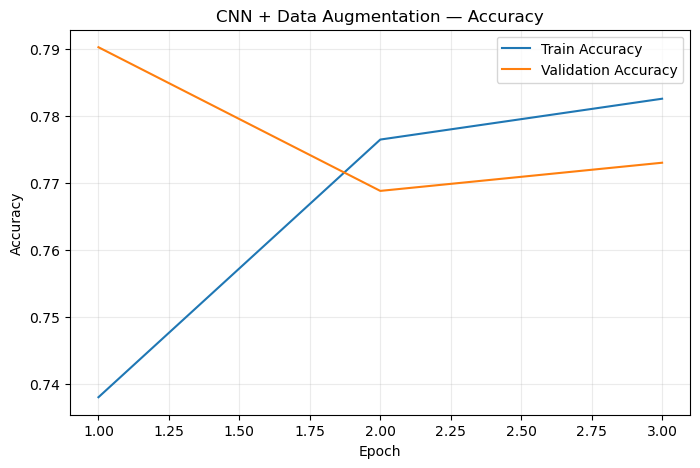

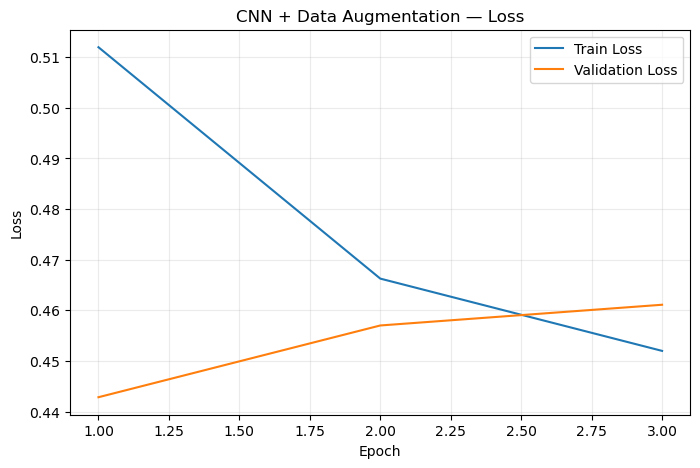

In [12]:
aug_history, aug_time = train_with_timer(
    aug_model, train_ds, val_ds, epochs=EPOCHS
)
print(f"Augmented CNN training time: {aug_time:.1f} seconds")
plot_history(aug_history, "CNN + Data Augmentation")


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Augmentation does not guarantee higher training accuracy. It deliberately makes the training examples harder and more varied; the important question is whether validation/test generalization improves.
</div>


<a id="section9"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Model C — Frozen MobileNetV2 Transfer Learning</h2>
MobileNetV2 is used here as the pre-trained feature extractor. Its convolutional backbone is frozen first, so only the new binary classification head is trained on our data.


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def build_transfer_model():
    backbone = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet",
    )
    backbone.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    compile_binary_model(model, learning_rate=1e-3)
    return model, backbone


transfer_model, base_model = build_transfer_model()
transfer_model.summary()


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> The first time you use <code>weights="imagenet"</code>, Keras may download the MobileNetV2 weights. In Google Colab this normally works automatically when internet access is available.
</div>


Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 163s 510ms/step - accuracy: 0.7834 - auc: 0.8648 - loss: 0.4585 - precision: 0.7861 - recall: 0.7375 - val_accuracy: 0.8362 - val_auc: 0.9189 - val_loss: 0.3759 - val_precision: 0.8921 - val_recall: 0.7511
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 163s 548ms/step - accuracy: 0.8302 - auc: 0.9107 - loss: 0.3769 - precision: 0.8342 - recall: 0.7948 - val_accuracy: 0.8349 - val_auc: 0.9244 - val_loss: 0.3682 - val_precision: 0.8976 - val_recall: 0.7424
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 157s 530ms/step - accuracy: 0.8364 - auc: 0.9145 - loss: 0.3686 - precision: 0.8414 - recall: 0.8011 - val_accuracy: 0.8493 - val_auc: 0.9277 - val_loss: 0.3407 - val_precision: 0.8640 - val_recall: 0.8157
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 196s 508ms/step - accuracy: 0.8424 - auc: 0.9197 - loss: 0.3568 - precision: 0.8474 - recall: 0.8085 - val_accuracy: 0.8451 - val_auc: 0.9289 - val_loss: 0.3423 - val_precision: 0.8746 - val_recall: 0.7921
Epoch 5/5
297/297 ━━

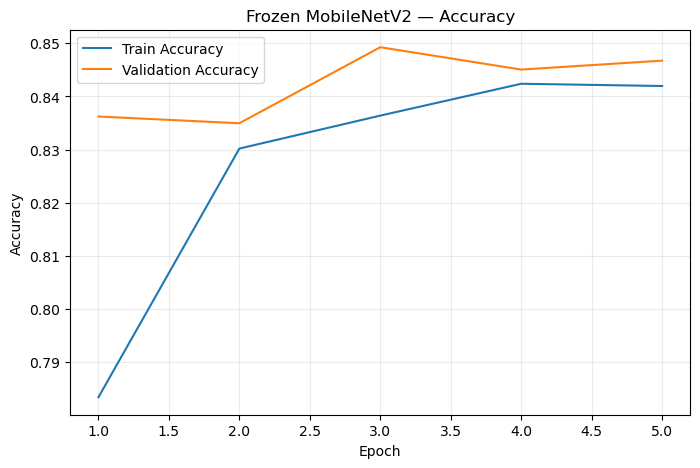

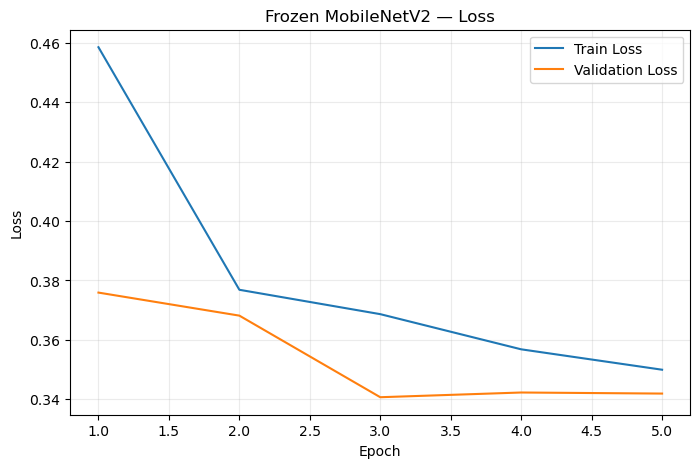

In [14]:
transfer_history, transfer_time = train_with_timer(
    transfer_model, train_ds, val_ds, epochs=EPOCHS
)
print(f"Frozen transfer-learning time: {transfer_time:.1f} seconds")
plot_history(transfer_history, "Frozen MobileNetV2")

# Keep a snapshot of the frozen-transfer model before fine-tuning changes its weights.
transfer_frozen_weights = transfer_model.get_weights()


<a id="section10"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">10. Fine-Tuning the Pre-trained Backbone</h2>
After the classifier head has learned the new task, we can unfreeze only the upper part of MobileNetV2 and continue training with a much smaller learning rate. This is optional but demonstrates the full freeze → fine-tune workflow.


In [15]:
# Unfreeze only the last part of MobileNetV2
base_model.trainable = True
FINE_TUNE_LAYERS = 30
fine_tune_at = max(0, len(base_model.layers) - FINE_TUNE_LAYERS)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNormalization layers are often kept frozen for stable fine-tuning on smaller datasets.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

compile_binary_model(transfer_model, learning_rate=1e-5)

print("Total backbone layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)
print("Trainable parameters after unfreezing:", sum(np.prod(v.shape) for v in transfer_model.trainable_weights))


Total backbone layers: 154
Fine-tuning from layer: 124
Trainable parameters after unfreezing: 1512001


Epoch 6/8
297/297 ━━━━━━━━━━━━━━━━━━━━ 196s 616ms/step - accuracy: 0.8430 - auc: 0.9224 - loss: 0.3506 - precision: 0.8485 - recall: 0.8088 - val_accuracy: 0.8522 - val_auc: 0.9342 - val_loss: 0.3300 - val_precision: 0.8825 - val_recall: 0.8000
Epoch 7/8
297/297 ━━━━━━━━━━━━━━━━━━━━ 182s 613ms/step - accuracy: 0.8631 - auc: 0.9377 - loss: 0.3146 - precision: 0.8664 - recall: 0.8362 - val_accuracy: 0.8472 - val_auc: 0.9387 - val_loss: 0.3406 - val_precision: 0.9107 - val_recall: 0.7572
Epoch 8/8
297/297 ━━━━━━━━━━━━━━━━━━━━ 182s 611ms/step - accuracy: 0.8696 - auc: 0.9430 - loss: 0.3013 - precision: 0.8735 - recall: 0.8434 - val_accuracy: 0.8657 - val_auc: 0.9394 - val_loss: 0.3156 - val_precision: 0.8853 - val_recall: 0.8288
Fine-tuning time: 580.5 seconds


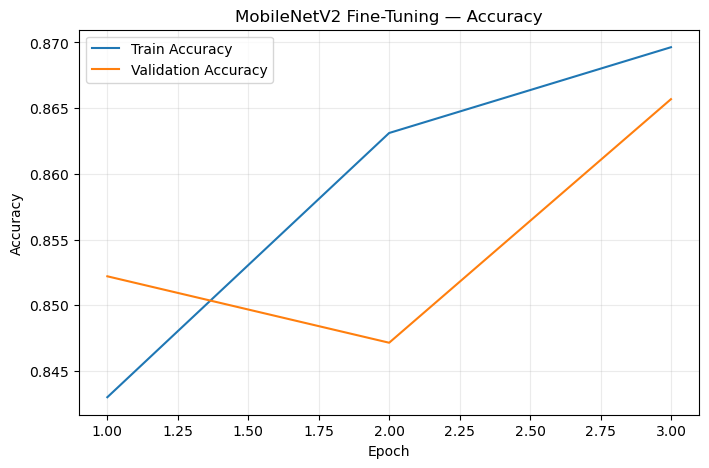

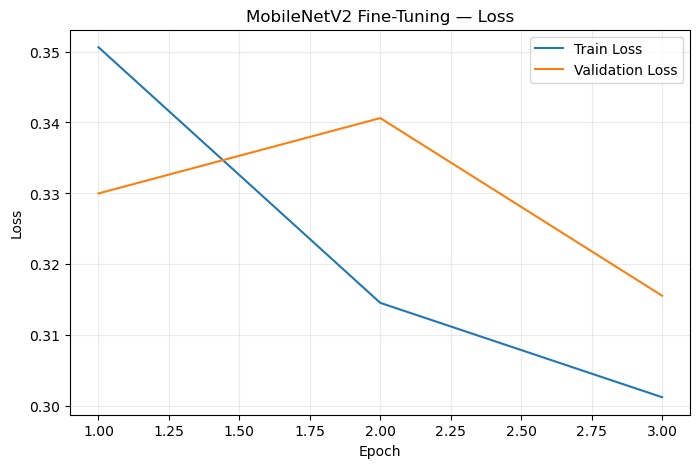

In [16]:
FINE_TUNE_EPOCHS = 3
initial_epoch = len(transfer_history.epoch)

tune_start = time.perf_counter()
fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=initial_epoch,
    epochs=initial_epoch + FINE_TUNE_EPOCHS,
    callbacks=make_callbacks(),
    verbose=1,
)
fine_tune_time = time.perf_counter() - tune_start

print(f"Fine-tuning time: {fine_tune_time:.1f} seconds")
plot_history(fine_tune_history, "MobileNetV2 Fine-Tuning")


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> If fine-tuning makes validation loss worse, keep the frozen transfer-learning result. Fine-tuning is useful only when it adds measurable generalization, not because it is a mandatory final step.
</div>


<a id="section11"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">11. Test Evaluation &amp; Model Comparison</h2>
The test split has not been used for training or validation. We now use it once for the final comparison.


In [17]:
def evaluate_on_test(name, model, training_seconds):
    metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
    row = {
        "model": name,
        "test_loss": metrics.get("loss", np.nan),
        "test_accuracy": metrics.get("accuracy", np.nan),
        "test_auc": metrics.get("auc", np.nan),
        "test_precision": metrics.get("precision", np.nan),
        "test_recall": metrics.get("recall", np.nan),
        "training_seconds": training_seconds,
    }
    return row

# Rebuild the frozen-transfer architecture and restore its pre-fine-tuning snapshot.
frozen_transfer_model, _ = build_transfer_model()
frozen_transfer_model.set_weights(transfer_frozen_weights)

results = [
    evaluate_on_test("Scratch CNN", scratch_model, scratch_time),
    evaluate_on_test("CNN + Augmentation", aug_model, aug_time),
    evaluate_on_test("Frozen MobileNetV2", frozen_transfer_model, transfer_time),
    evaluate_on_test("MobileNetV2 + Fine-Tuning", transfer_model, transfer_time + fine_tune_time),
]

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "test_loss": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_auc": "{:.4f}",
    "test_precision": "{:.4f}",
    "test_recall": "{:.4f}",
    "training_seconds": "{:.1f}",
}))


,model,test_loss,test_accuracy,test_auc,test_precision,test_recall,training_seconds
0,MobileNetV2 + Fine-Tuning,0.3147,0.8625,0.9499,0.9191,0.7950,1461.5
1,Frozen MobileNetV2,0.3428,0.8480,0.9390,0.9123,0.7700,881.0
2,Scratch CNN,0.4657,0.7805,0.8838,0.8288,0.7070,765.3
3,CNN + Augmentation,0.5232,0.7295,0.8195,0.7302,0.7280,457.1


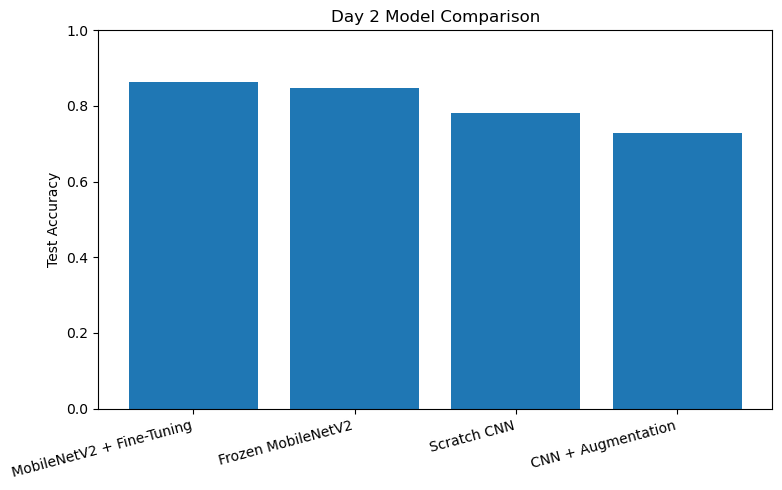

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["test_accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Day 2 Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">11.1 Confusion matrix and classification report for the best model</h3>


Best model: MobileNetV2 + Fine-Tuning

Classification report:

              precision    recall  f1-score   support

      Benign     0.8194    0.9300    0.8712      1000
   Malignant     0.9191    0.7950    0.8525      1000

    accuracy                         0.8625      2000
   macro avg     0.8692    0.8625    0.8619      2000
weighted avg     0.8692    0.8625    0.8619      2000



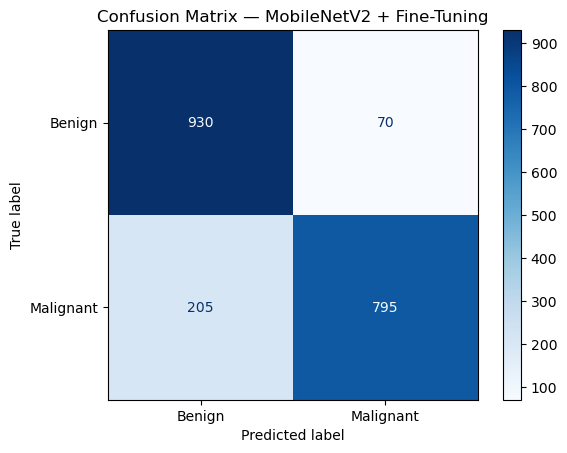

In [19]:
# Select the model object corresponding to the best test-accuracy row.
model_lookup = {
    "Scratch CNN": scratch_model,
    "CNN + Augmentation": aug_model,
    "Frozen MobileNetV2": frozen_transfer_model,
    "MobileNetV2 + Fine-Tuning": transfer_model,
}

best_name = results_df.loc[0, "model"]
best_model = model_lookup[best_name]

true_labels = np.concatenate([y.numpy().ravel() for _, y in test_ds]).astype(int)
probabilities = best_model.predict(test_ds, verbose=0).ravel()
pred_labels = (probabilities >= 0.5).astype(int)

print("Best model:", best_name)
print("\nClassification report:\n")
print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Accuracy is useful here because the test split is balanced at 1,000 Benign and 1,000 Malignant images. Still, precision, recall, AUC, and the confusion matrix show <i>which</i> type of error the model makes.
</div>


<a id="section12"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">12. Common Mistakes &amp; Best Practices</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li><b>Augmenting validation/test data</b> — random augmentation belongs only in the training pipeline.</li>
<li><b>Using the test set to choose a model</b> — choose design decisions using validation data; use the test set for the final unbiased check.</li>
<li><b>Forgetting model-specific preprocessing</b> — MobileNetV2 expects <code>preprocess_input</code>, not the same 0–1 normalization used by the scratch CNN.</li>
<li><b>Unfreezing the whole pre-trained model immediately</b> — first train the new head with the backbone frozen.</li>
<li><b>Fine-tuning with a large learning rate</b> — use a much smaller rate such as <code>1e-5</code> to avoid damaging pre-trained features.</li>
<li><b>Comparing only training accuracy</b> — validation/test curves and metrics are what tell you whether generalization improved.</li>
<li><b>Ignoring class labels</b> — always confirm the directory-to-label mapping printed by TensorFlow.</li>
</ul>
</div>


<a id="section13"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">13. Final Reflection</h2>
Use the values produced by the comparison table to complete this short conclusion after running the notebook.

<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:12px 16px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Reflection Template</b>
<ul>
<li>The CNN from scratch achieved a test accuracy of <b>_____</b>.</li>
<li>After data augmentation, the test accuracy became <b>_____</b>, and the validation curves showed <b>_____</b>.</li>
<li>The frozen MobileNetV2 model achieved <b>_____</b> test accuracy in <b>_____</b> seconds.</li>
<li>After fine-tuning, MobileNetV2 achieved <b>_____</b> test accuracy.</li>
<li>The best approach was <b>_____</b> because <b>_____</b>.</li>
<li>Fine-tuning <b>improved / did not improve</b> performance because <b>_____</b>.</li>
</ul>
</div>


<a id="section14"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">14. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> <ul>
<li><b>Pooling</b> shrinks feature maps and keeps strong local signals, reducing computation and sensitivity to small shifts.</li>
<li>A complete <b>CNN</b> combines convolution, pooling, and a classifier head to learn visual features directly from images.</li>
<li><b>Data augmentation</b> creates random realistic training variations and is a standard defense against overfitting in computer vision.</li>
<li><b>Transfer learning</b> reuses a pre-trained visual backbone such as MobileNetV2, often achieving stronger results from less data and compute.</li>
<li><b>Freezing</b> protects pre-trained weights while the new classifier learns; <b>fine-tuning</b> later adapts a small part of the backbone using a very small learning rate.</li>
<li>A fair experiment compares models using the same split, the same seed, validation curves, final test metrics, and training time.</li>
</ul>
</div>


<div style="margin-top:30px; padding:14px; border:1px solid #ddd; border-radius:6px; color:#52677A; text-align:center;">
<b>Week 7 — Day 2 Complete</b><br>
Next: sequential data, RNNs and LSTMs.
</div>
